In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

## 1st practice

In [28]:
class BaseClass(TypedDict):
    height_m : float
    weight_kg : float
    bmi : float


def calculate_bmi(state: BaseClass) -> BaseClass:
    height_m = state['height_m']
    weight_kg = state['weight_kg']
    state['bmi'] = weight_kg / (height_m ** 2)

    return state

In [29]:
graph = StateGraph(BaseClass)

In [30]:
graph.add_node('calculate_bmi', calculate_bmi)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)



In [31]:
app = graph.compile()

In [43]:
initial_state = {"height_m" : 50, "weight_kg" : 60}
end_state = app.invoke(initial_state)

print(end_state['bmi'])

0.024


## 2nd practice

In [63]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [60]:
load_dotenv()
llm = ChatGroq(model='llama-3.1-8b-instant')

In [67]:
class OutlineState(TypedDict):
    topic : str
    outline : str
    blog : str

def gen_outline(state : OutlineState) -> OutlineState:
    topic = state['topic']

    prompt = PromptTemplate(
        template="""
            generate outline for given topic: {topic}
        """,
        input_variables=['topic']
    )
    parser = StrOutputParser()
    chain = prompt | llm | parser

    state['outline'] = chain.invoke({'topic': topic})

    return state


def gen_blog(state : OutlineState) -> OutlineState:
    topic = state['topic']
    outline = state['outline']

    prompt = PromptTemplate(
            template="""
                generate blog for given topic and outline.\n
                topic: {topic}\n
                outline: {outline}
            """,
            input_variables=['topic', 'outline']
        )
    parser = StrOutputParser()
    chain = prompt | llm | parser

    state['blog'] = chain.invoke({'topic': topic, 'outline': outline})

    return state


In [68]:
graph_2 = StateGraph(OutlineState)

graph_2.add_node('gen_outline', gen_outline)
graph_2.add_node('gen_blog', gen_blog)

graph_2.add_edge(START, 'gen_outline')
graph_2.add_edge("gen_outline", 'gen_blog')
graph_2.add_edge('gen_blog', END)

workflow = graph_2.compile()

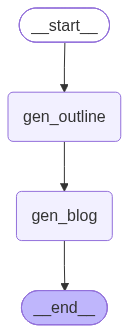

In [71]:
workflow

In [70]:
initial_state = {'topic': 'Mechine learning in Medical Industry'}
final_state = workflow.invoke(initial_state)

print(final_state['blog'])

**Machine Learning in Medical Industry: Revolutionizing Healthcare**

**Introduction**

Machine learning, a subset of artificial intelligence, has been gaining significant attention in recent years for its potential to transform various industries, including the medical industry. The medical industry is one of the most data-intensive and complex sectors, where machine learning can help improve patient outcomes, reduce costs, and enhance the overall quality of care.

**Definition of Machine Learning and its Relevance to the Medical Industry**

Machine learning is a type of artificial intelligence that enables computers to learn from data without being explicitly programmed. It involves training algorithms on large datasets to make predictions or decisions. In the medical industry, machine learning can be applied to various areas, including diagnostics, personalized medicine, and clinical decision support systems.

**The Medical Industry's Need for Machine Learning**

The medical industr